<a href="https://colab.research.google.com/github/eshajain-123/csot-ml-astronomy/blob/main/week5_lens_vlm_starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q datasets transformers accelerate qwen-vl-utils scikit-learn

In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

Using: cuda


In [4]:
from datasets import load_dataset
ds_test = load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification', split='test')
y_all = np.array(ds_test['label'])
rng = np.random.default_rng(42)
pos = rng.choice(np.where(y_all == 1)[0], size=20, replace=False)
neg = rng.choice(np.where(y_all == 0)[0], size=20, replace=False)
idx = np.concatenate([pos, neg]); rng.shuffle(idx)
images = [ds_test[int(i)]['image'].convert('RGB') for i in idx]
labels = y_all[idx]
print('sample size:', len(images), 'positives:', int(labels.sum()))

sample size: 40 positives: 20


Dataset({
    features: ['image', 'response'],
    num_rows: 40
})


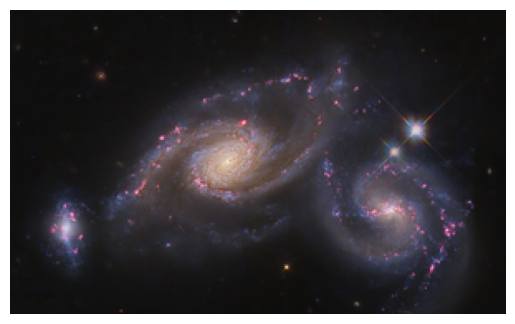

This is a pair of interacting spiral galaxies. They are actually very close together, and not merely nearby on the sky. This image does not show an instance of strong gravitational lensing.


In [5]:
ref = load_dataset('Arbie333/gravitational_lensing', split='train')
print(ref)
import matplotlib.pyplot as plt

plt.imshow(ref[0]["image"])
plt.axis("off")
plt.show()

print(ref[0]["response"])

In [6]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
model_id = 'Qwen/Qwen2-VL-2B-Instruct'
vlm = Qwen2VLForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.float16, device_map='auto')
processor = AutoProcessor.from_pretrained(model_id)

PROMPT = (
'You are assisting an astronomer reviewing telescope cutouts for strong gravitational lensing.\n\n'
'Look at this image. Strong lensing shows clear arcs, partial Einstein rings, or multiple images '
'of a background source.\n\n'
'Answer in this format:\n'
'VERDICT: yes | no | uncertain\n'
'EVIDENCE: one or two sentences describing what you see (or do not see)\n'
'CAUTION: one sentence about what could be confused with lensing (e.g. spiral arms, mergers)')


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

In [7]:
raw_answers = []
for img in images:
    messages = [{'role': 'user', 'content': [
        {'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT}]}]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=[img], return_tensors='pt').to(vlm.device)
    with torch.no_grad():
        out = vlm.generate(**inputs, max_new_tokens=128, do_sample=False)
    reply = processor.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
    raw_answers.append(reply)
print(raw_answers[0])

VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


In [8]:
def parse_verdict(text):
  for line in text.splitlines():
    if line.strip().upper().startswith('VERDICT'):
      v = line.split(':', 1)[1].strip().lower()
    if 'yes' in v:
      return 'yes'
    if 'uncertain' in v:
      return 'uncertain'
    if 'no' in v:
      return 'no'
  return 'uncertain'
verdicts = [parse_verdict(t) for t in raw_answers]
vlm_pred = np.array([1 if v == 'yes' else 0 for v in verdicts])  # uncertain -> 0
from sklearn.metrics import classification_report
print(classification_report(labels, vlm_pred, target_names=['not lens', 'lens']))

              precision    recall  f1-score   support

    not lens       0.00      0.00      0.00        20
        lens       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


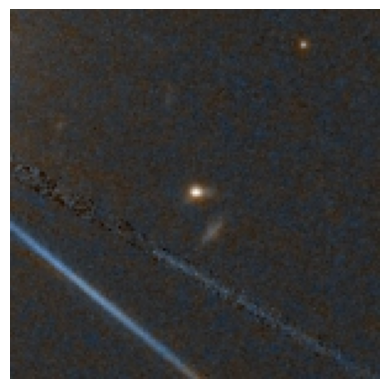

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


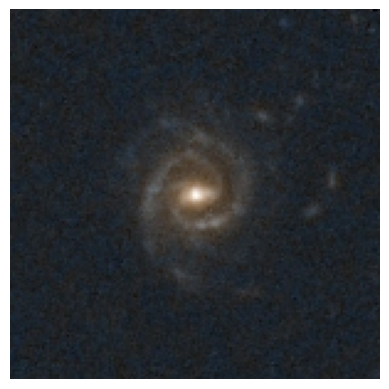

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered around the galaxy and extends outward, indicating the presence of a strong gravitational lens. There are no other visible features such as spiral arms or mergers that could be confused with lensing.
CAUTION: The arc could also be due to the galaxy itself, as it is a common feature of spiral galaxies. However, the arc is clearly visible and does not appear to be due to the galaxy itself.


In [9]:
halluc = [i for i in range(len(images)) if vlm_pred[i] == 1 and labels[i] == 0]
for i in halluc[:2]:
  plt.imshow(images[i]); plt.axis('off'); plt.show()
  print('VLM said:', raw_answers[i])

In [10]:
import torch.nn as nn
from torchvision import transforms
class GalaxyCNN(nn.Module):
  def __init__(self, num_classes=3):
    super().__init__()
    self.features = nn.Sequential(
               nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
               nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
    self.classifier = nn.Sequential(
               nn.Flatten(), nn.Linear(32*16*16, 128), nn.ReLU(), nn.Linear(128, num_classes))
  def forward(self, x): return self.classifier(self.features(x))
CLASSES = ['elliptical', 'spiral', 'lenticular']  # use YOUR Week-3 train_ds.classes order
cnn = GalaxyCNN(num_classes=len(CLASSES)).to(device)
cnn.load_state_dict(torch.load('galaxy_model.pth', map_location=device)); cnn.eval()
tf = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])
cnn_pred = []
for img in images:
  x = tf(img).unsqueeze(0).to(device)
  with torch.no_grad():
    cnn_pred.append(CLASSES[cnn(x).argmax(1).item()])

In [11]:
print("model" in globals())
print("processor" in globals())
print("text_emb" in globals())
print("images" in globals())

False
True
False
True


In [12]:
from transformers import CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [13]:
lens_prompts = [
    "a strong gravitational lens with an Einstein ring",
    "a gravitational lens arc next to a galaxy",
    "multiple images of a background source due to gravitational lensing"
]

nonlens_prompts = [
    "a normal galaxy without gravitational lensing",
    "a spiral galaxy with curved arms but no gravitational lens arc",
    "a smooth elliptical galaxy with no lensing features"
]

all_prompts = lens_prompts + nonlens_prompts

In [14]:
import transformers
import torch

print(transformers.__version__)
print(torch.__version__)

5.13.1
2.11.0+cu128


In [15]:
from transformers import CLIPModel, CLIPProcessor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

inputs = processor(text=["galaxy"], return_tensors="pt", padding=True).to(device)

with torch.no_grad():
    out = model.get_text_features(**inputs)

print(type(out))

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

<class 'transformers.modeling_outputs.BaseModelOutputWithPooling'>


In [16]:
import torch.nn.functional as F

text_inputs = processor(
    text=all_prompts,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():

    text_out = model.get_text_features(
        input_ids=text_inputs["input_ids"],
        attention_mask=text_inputs["attention_mask"]
    )

text_emb = F.normalize(text_out.pooler_output, dim=-1)

n_lens = len(lens_prompts)

In [17]:
print(text_emb.shape)

torch.Size([6, 512])


In [18]:
import torch
import torch.nn.functional as F
import numpy as np

clip_scores = []

with torch.no_grad():
    for img in images:

        # Process one image
        image_inputs = processor(
            images=img,
            return_tensors="pt"
        ).to(device)

        # Get image embedding
        img_out = model.get_image_features(
            pixel_values=image_inputs["pixel_values"]
        )

        # Your transformers version returns BaseModelOutputWithPooling
        img_emb = F.normalize(img_out.pooler_output, dim=-1)

        # Similarity with all prompts
        sims = img_emb @ text_emb.T

        # Average lens vs non-lens similarity
        lens_sim = sims[:, :n_lens].mean(dim=1)
        nonlens_sim = sims[:, n_lens:].mean(dim=1)

        score = (lens_sim - nonlens_sim).item()
        clip_scores.append(score)

clip_scores = np.array(clip_scores)

print("Finished!")
print("Score range:", clip_scores.min(), clip_scores.max())

Finished!
Score range: -0.024023354053497314 0.011183500289916992


In [19]:
print(type(images), len(images))
print(type(labels), len(labels))
print(type(cnn_pred), len(cnn_pred))
print(type(clip_scores), len(clip_scores))
print(type(verdicts), len(verdicts))

<class 'list'> 40
<class 'numpy.ndarray'> 40
<class 'list'> 40
<class 'numpy.ndarray'> 40
<class 'list'> 40


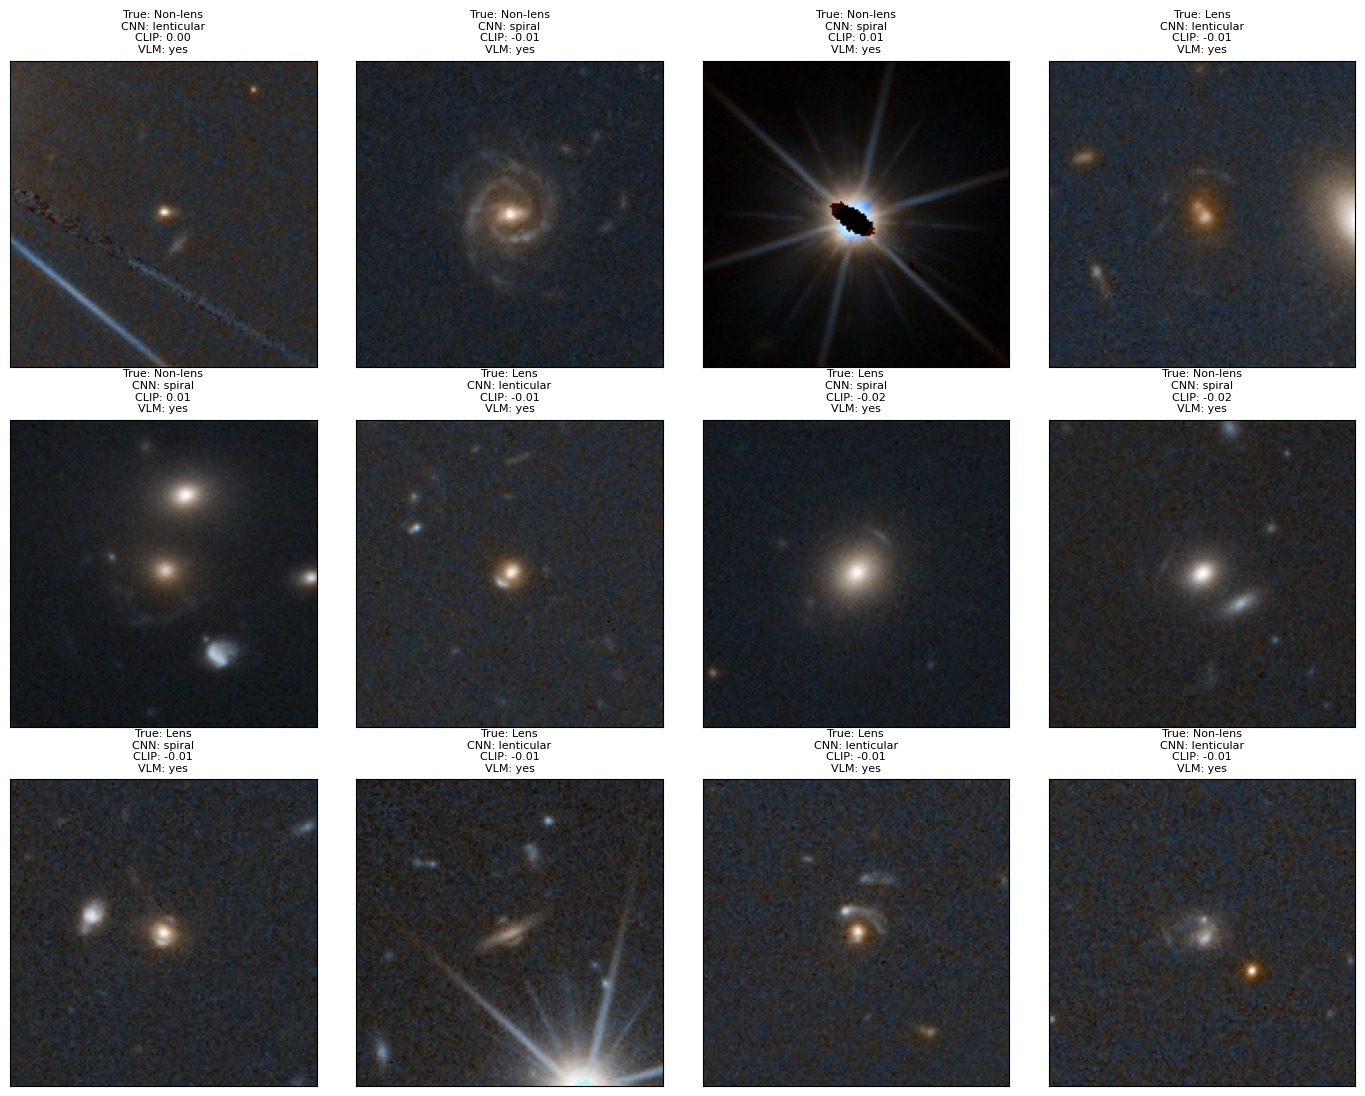

In [20]:
import matplotlib.pyplot as plt

n = min(12, len(images))

fig, axes = plt.subplots(3, 4, figsize=(14, 11))

for ax, i in zip(axes.ravel(), range(n)):
    ax.imshow(images[i])
    ax.set_xticks([])
    ax.set_yticks([])

    # Convert numeric labels to readable text
    true_label = "Lens" if labels[i] == 1 else "Non-lens"

    ax.set_title(
        f"True: {true_label}\n"
        f"CNN: {cnn_pred[i]}\n"
        f"CLIP: {clip_scores[i]:.2f}\n"
        f"VLM: {verdicts[i]}",
        fontsize=8
    )

plt.tight_layout()
plt.show()